# Clasificación de intención crediticia

### Tres enfoques:
1. **LaBSE + lr** (baseline simulado)
2. **TF-IDF + LR**
2. **BERT Fine-tuning** (Fine-tuning sobre transformers)

---

## 0. Setup y dependencias

In [2]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    hamming_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    average_precision_score,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import warnings

from utils.utils import (
    clean_text,
    norm_key,
    tune_thresholds,
    ablation_lr,
)
import json
from typing import Union

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)
from sentence_transformers import SentenceTransformer
import torch
from torch.utils.data import Dataset
from safetensors.torch import load_file
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
DATA_PATH = "data/intent.csv"

# Deficinicion de labels
intent = pd.read_csv(DATA_PATH)
LABELS = [c for c in intent.columns if c != "motivos"]
LABEL_NAMES = {
    "crec": "Growth",
    "cred": "Pay Debts",
    "equ": "Buy Equipment",
    "inic": "Start Business",
    "inv": "Inventory",
    "mkt": "Marketing",
    "no": "Other/Not Working",
    "renta": "Rent",
    "sueldo": "Payroll",
    "temp": "Seasonal",
}
print(f"Columnas: {intent.columns}")

Columnas: Index(['motivos', 'crec', 'cred', 'equ', 'inic', 'inv', 'mkt', 'no', 'renta',
       'sueldo', 'temp'],
      dtype='str')


## 1. Business Understanding
---

**Contexto.** En el funnel de originación, la empresa pregunta al cliente para qué necesita el crédito. Se tiene que convertir esa respuesta en etiquetas estructuradas, de manera que ayude en:
1. **Riesgo:** distinguir capital de trabajo productivo (`inv`, `equ`, `crec`) de refinanciamiento de deuda (`cred`) o gasto no productivo (`no`).
2. **Producto y pricing:** ofrecer líneas y plazos acordes (p. ej. `temp` -> estacionalidad, `sueldo` -> nómina).
3. **Operación y analítica:** segmentación, detección de solicitudes inconsistentes, cobertura multilingüe.

**Problema de Machine Learning** Clasificación de texto multi-label, es decir, una solicitud puede tener varios propósitos, textos cortos en español, clases muy desbalanceadas.

**Referencia interna.** Binary Relevance + LogReg sobre LASER: Hamming loss 0.068 y average precision ≈ 67 %, con `temp` como clase más débil.

## 2. Data Understanding
---

A continuación, veremos el analisis de los datos a disposición, entendiendo un poco más de su estructura.

    crec   cred     equ   inic     inv    mkt     no  renta  sueldo   temp
n  600.0  429.0  1980.0  381.0  2318.0  329.0  444.0  770.0   215.0  189.0
%    9.0    6.4    29.6    5.7    34.7    4.9    6.6   11.5     3.2    2.8

Etiquetas por registro: {0.0: 1, 1.0: 5769, 2.0: 841, 3.0: 68}
Palabras por texto: {'count': 6679.0, 'mean': 14.6, 'std': 9.6, 'min': 1.0, '50%': 11.0, '90%': 27.0, '99%': 48.0, 'max': 223.0}
Distribución de clases
  Seasonal            :   189 (  2.8%)


C:\Users\Miguel\AppData\Local\Temp\ipykernel_23896\968105451.py:4: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  nlab = Y.sum(1)


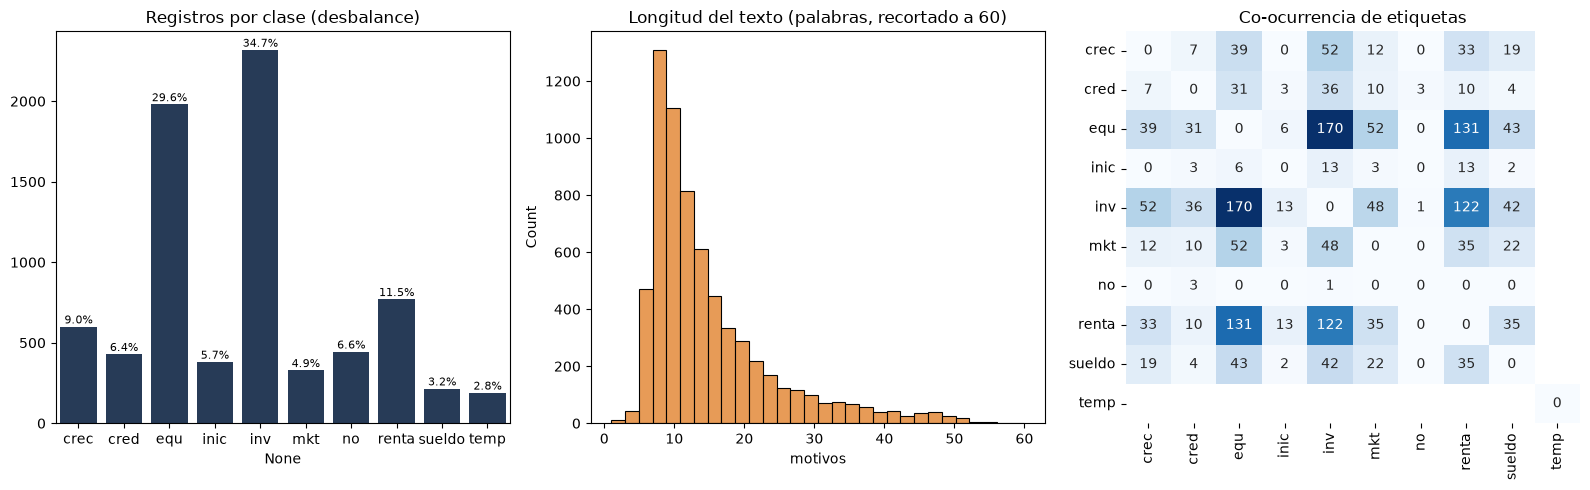

In [4]:
Y = intent[LABELS]
PAL = ["#1f3a5f", "#e07a1f", "#2a9d8f", "#8a5a9e", "#888888"]
counts = Y.sum()
nlab = Y.sum(1)
words = intent.motivos.map(lambda t: len(clean_text(t).split()))


print(
    pd.DataFrame(
        {"n": counts, "%": (counts / len(intent) * 100).round(1)}
    ).T.to_string()
)

# como vemos hay registros con más de una etiqueta:
print("\nEtiquetas por registro:", nlab.value_counts().sort_index().to_dict())
print(
    "Palabras por texto:",
    words.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_dict(),
)


# Label distribution
print("Distribución de clases")
label_dist = intent[LABELS].sum().sort_values(ascending=False)
for label, count in label_dist.items():
    pct = count / len(intent) * 100
print(f"  {LABEL_NAMES[label]:20s}: {int(count):5d} ({pct:5.1f}%)")



fig, ax = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(x=counts.index, y=counts.values, color=PAL[0], ax=ax[0])
ax[0].set_title("Registros por clase (desbalance)")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 20, f"{v/len(intent)*100:.1f}%", ha="center", fontsize=8)

sns.histplot(words.clip(upper=60), bins=30, color=PAL[1], ax=ax[1])
ax[1].set_title("Longitud del texto (palabras, recortado a 60)")

co = (Y.T @ Y).values.astype(float)
np.fill_diagonal(co, 0)
sns.heatmap(
    pd.DataFrame(co, LABELS, LABELS),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=False,
    ax=ax[2],
)
ax[2].set_title("Co-ocurrencia de etiquetas")

plt.tight_layout()
# plt.savefig('figs/fig1_eda.png', dpi=160);
plt.show()

1. **Desbalance de clases** Como vemos, es bastante notorio que existe un desbalance de clases, esto puede tener a posteriori varias repercusiones si no se tratan debidamente, como un modelo sesgado y una metrica que engañe al evaluador. En este sentido, y como tenemos pocos datos, podemos entrenar los modelos subsecuentes con una función de perdida pesada, de manera que represente correctamente el impacto de cada clase a la hora de entrenar.

2. **Distribución normal** sobre la longitud de las cadenas de texto, que representan nuestra variable intependiente. Esto es de esperarse.

3. **Co-ocurrencia** de variables, a partir de este grafico, se presenta cuantos registros tienen simultaneamente dos etiquetas. Como podemos ver, algunas ocurrencias como inv- equ aparecen mucho más.

# 3. Data Preparation

---

### Valores nulos

Podemos vel los siguientes valores nulos. Como vemos, la cantidad es poca, no representan una muestra representativa, por lo que intentar una estrategia para imputar los valores perdidos no generaría un impacto real en el entrenamiento de los modelos, por lo que los eliminamos.

In [5]:
nans = intent[intent.isnull().any(axis=1)]
print(nans)
intent = intent.drop(nans.index)
print(f"Filas despues de remover nulos: {len(intent)}")

                                                motivos  crec  cred  equ  \
628   CAPITAL DE TRABAJO COMPRA DE MATERIA Y MANO DE...     0     0    0   
710           Para incrementar ventas tener inventarios     0     0    0   
1130  Capital de trabajo\n,0,0,0,0,0,0,0,1,0,0\nRe i...     0     0    0   
1437           Tengo que hacer renovación de Consepción     0     0    0   
1699    PARA LA COMPRA DE ACTIVOS FIJOS PARA LA EMPRESA     0     0    0   
2263  Compra de equipos de cómputo para lanzar proye...     0     1    0   

      inic  inv  mkt  no  renta  sueldo  temp  
628      1    0    0   0      1       0   NaN  
710      1    0    0   0      0       0   NaN  
1130     0    0    0   0      0       0   NaN  
1437     0    0    1   0      0       0   NaN  
1699     1    0    0   0      0       0   NaN  
2263     0    0    0   0      0       0   NaN  
Filas despues de remover nulos: 6673


### Duplicados

Al igual que los valores nulos, estos deben eliminarse, pero aquí podemos distinguir una razón particular: veamos que el subconjunto bajo el cual se calculan los valores nulos es es nuestra variable predictora `motivos` y no sobre las clases. Por la naturaleza del problema, y por que esta variable representa datos o respuestas humanas, un duplicado de este tipo implicaría más un error que un outlier o un evento estadisticamente significativo. A pesar de que esta tarea representa que una muestra más grande será eliminada, no hay forma de que podamos imputar estos valores, pues no existe otra variable independiente.

In [6]:
duplicates = intent[intent.duplicated(subset=["motivos"])]
print(duplicates)
print(f"Número de duplicados: {len(duplicates)}")
# Ejemplo de duplicado:
intent[intent["motivos"] == "Marketing y publicidad , adquisicion de equipo de computo"]


intent = intent.drop_duplicates(subset=["motivos"])
print(f"Filas despues de remover duplicados: {len(intent)}")

                                                motivos  crec  cred  equ  \
115   Marketing y publicidad , adquisicion de equipo...     0     0    0   
452   adquisición de insumos, materiales  y financia...     0     0    0   
487           REFINANCIAMIENTO PARA CAPTAR MAS CLIENTES     1     0    0   
577     Adquisicion de equipo y software e intalaciones     0     0    1   
592   adquisición de insumos, materiales  y financia...     0     0    0   
...                                                 ...   ...   ...  ...   
6226  Comprar equipo de impresión y corte laser, imp...     0     0    1   
6257  Mi negocio es una Lavanderia con renta de mant...     0     0    0   
6277      capital de trabajo para comprar materia prima     0     0    0   
6431  Proyectos en Puerta, Cableado Estructurado y CCTV     0     0    1   
6493  En materia prima e insumos y  operación del ne...     0     0    0   

      inic  inv  mkt  no  renta  sueldo  temp  
115      0    0    1   0      0       0

A pesar de que contamos con algunos caracteres especiales como `#, !, \`, no los eliminaremos, ya que estos pueden aportar información semántica, como en el caso del siguiente registro: El # aporta el contexto de número de cedula al registro.

In [7]:
mask = intent["motivos"].str.contains(r"[@#\\]", na=False, regex=True)

df_con_especiales = intent.loc[mask, ["motivos"]]
print(df_con_especiales.iloc[1]["motivos"])

En comprar equipo - maquina de impresión doble carta de offset- para imprimir revistas y libros y crear una editorial, soy Licenciado en Diseño Gráfico con cédula profesional # 4119172, egresado de la Universidad de las Américas Puebla y con maestría


Aunado a lo anterior, podemos aplicar una leve normalización en el texto, de manera que, por ejemplo, eliminar caracteres que no aportan información como espacios de más. Y nuevamente revisar si existen si existen registros que pueden considerarse como duplicados

In [8]:
# Calidad de etiquetas: textos idénticos con etiquetas distintas
# pendiente, verificar cual de las copias debemos eliminar
tmp = intent.copy()
tmp["text"] = tmp["motivos"].map(clean_text)
tmp["key"] = tmp["motivos"].map(norm_key)
group = tmp.groupby("key")  # se agrupa por misma key
dup_groups = group.filter(lambda x: len(x) > 1)  # grupos donde hay más de un registro
dg_different_label = dup_groups.groupby("key").filter(
    lambda x: len(x[LABELS].drop_duplicates()) > 1
)  # aca son duplicados con etiquetas diferentes
print(f"Registros en grupos duplicados: {len(dup_groups)})")
print(f"Grupos con etiquetas contradictorias: {dg_different_label.key.nunique()}")
# Ejemplos:
examples = dg_different_label.groupby("key").head(3).sort_values("key").head(12)
examples["labels"] = examples[LABELS].apply(
    lambda r: ",".join([l for l in LABELS if r[l]]), axis=1
)
examples.sort_values(by="text")
display(examples[["text", "labels"]].reset_index(drop=True))

Registros en grupos duplicados: 29)
Grupos con etiquetas contradictorias: 5


,text,labels
0,Ampliar mi negocio y comprar mas mercancia,"crec,inv"
1,Ampliar mi negocio. Y comprar mas mercancia,inv
2,"CAPITAL DE TRABAJO, GASTOS DE OPERACION Y COMP...","equ,inv"
3,"Capital de trabajo, gastos de operación y comp...",equ
4,"CAPITAL DE TRABAJO, GASTOS DE OPERACIÓN Y COMP...","equ,inv"
5,"Capital de trabajo, para crecimiento de la emp...",inv
6,Capital de trabajo para crecimiento de la empresa,crec
7,LO UTILIZAREMOS PARA CAPITAL DE TRABAJO E INOV...,crec
8,lo utilizaremos para capital de trabajo e inov...,inv
9,lo utilizaremos para capital de trabajo e inov...,"equ,renta"


Aplicamos la normalización de texto y la eliminación de los nuevos duplicados detectados

In [9]:
filt_intent = intent.copy()
filt_intent["motivos"] = filt_intent["motivos"].map(clean_text)  # normalizacion
filt_intent["key"] = filt_intent["motivos"].map(norm_key)
n_0 = len(filt_intent)
# conflict = filt_intent.groupby('key')[LABELS].nunique().max(axis=1).gt(1).sum()
filt_intent = filt_intent.drop_duplicates("key", keep="first").reset_index(drop=True)
filt_intent = filt_intent[filt_intent[LABELS].sum(axis=1) > 0].reset_index(
    drop=True
)  # sin ninguna etiqueta -> fuera
print(f"Filas removidas {n_0 - len(filt_intent)}")
# return filt_intent, dict(n_before=n_0, n_after=len(filt_intent), dup_removed=n_0 - len(filt_intent), dup_conflicts=int(conflict))

Filas removidas 16


In [10]:
# Preparamos datos
mask = filt_intent[LABELS].sum(axis=1) > 0
filt_intent = filt_intent[
    mask
].copy()  # eliminamos aquellas celdas con clases totalmente en 0's
print(f"Longitud final: {len(filt_intent)}")

Longitud final: 6498


### Division de conjunto de entrenamiento, validación y prueba: 

¿Por que dividir en un tercer conjunto de validación?

Es una buena practica para el ajuste de hiper parametros, además de que reservamos el test de prueba a fungir como gold estandar para comparación al final del desarrollo.

In [11]:
X = filt_intent["motivos"].reset_index(drop=True)
y = filt_intent[LABELS].reset_index(drop=True).astype(int)
s_var = y.sum(axis=1)

# split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=s_var
)

s_var = y_temp.sum(axis=1)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=s_var
)

print(f"Division de entrenamiento, validación y prueba:-")
print(f" Train: {len(X_train)} ejemplos ({len(X_train)/len(filt_intent)*100:.1f}%)")
print(f" Valid:  {len(X_valid)} ejemplos ({len(X_valid)/len(filt_intent)*100:.1f}%)")
print(f" Test:  {len(X_test)} ejemplos ({len(X_test)/len(filt_intent)*100:.1f}%)")

Division de entrenamiento, validación y prueba:-
 Train: 5198 ejemplos (80.0%)
 Valid:  650 ejemplos (10.0%)
 Test:  650 ejemplos (10.0%)


# 4. Entrenamiento de modelos
---

## 4.0 LaBSE (Google) + Logistic Regression

Como se menciona en el problema de negocio, el enfoque usado como baseline usa un embedding Laser (Meta) para la variable `motivos` junto con una regresión lineal con un enfoque por descomposicion "Binary Relevance" (En este enfoque un clasificador es entrenado contra todas las demás clases, es decir la salida de cada uno es binaria, de manera que mejora la interpretabilidad del modelo). 

Por problemas de dependencias, en este experimento se usará un embedding LaBSE, una adaptación de BERT que se encarga de generar embeddings (https://www.kaggle.com/models/google/labse/tensorFlow2/labse/1?tfhub-redirect=true), notemos que, aunque los vectores de salida pueden ser diferentes, el enfoque de la tarea sigue siendo el mismo.

**Nota:**
- C se elige en validación.
- Los umbrales se ajustan después, con C ya fijo.

In [12]:
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"  # desactivamos algunas warnings
import logging

logging.getLogger("httpx").setLevel(logging.WARNING)

print(
    "Enfoque 0: LaBSE + Regresión Logística (Binary Relevance, class_weight + umbrales por etiqueta)"
)

# Embeddings LaBSE
encoder = SentenceTransformer("sentence-transformers/LaBSE").to(device)
e_train_bse = encoder.encode(list(X_train), batch_size=64, normalize_embeddings=True)
e_valid_bse = encoder.encode(list(X_valid), batch_size=64, normalize_embeddings=True)
e_test_bse = encoder.encode(list(X_test), batch_size=64, normalize_embeddings=True)
print(f"Embeddings: {e_train_bse.shape}")


best = {"C": None, "ap": -np.inf}
for C in [0.1, 1, 10, 100]:
    clf = OneVsRestClassifier(
        LogisticRegression(
            C=C,  # parametro contrario a la regularizacion
            # class_weight="balanced",
            max_iter=1000,
            random_state=42,
        )
    )
    clf.fit(e_train_bse, y_train)
    ap = average_precision_score(
        y_valid, clf.predict_proba(e_valid_bse), average="macro"
    )
    print(f"  C={C:<6} val macro AP={ap:.4f}")
    if ap > best["ap"]:
        best = {"C": C, "ap": ap, "clf": clf}

print(f"\nMejor valor C: {best['C']}")

# Umbrales por etiqueta: se aprenden en validacion
p_valid_a0 = best["clf"].predict_proba(e_valid_bse)
thresholds_a0 = tune_thresholds(y_valid, p_valid_a0)
print("\nUmbrales por etiqueta (validación):")
print(pd.Series(thresholds_a0, index=LABELS).round(2).to_dict())

# Evaluación en test: umbrales ya fijos
y_pred_prob_a0 = best["clf"].predict_proba(e_test_bse)
y_pred_a0 = (y_pred_prob_a0 > thresholds_a0).astype(int)
# y_pred_a0 = (y_pred_prob_a0 > 0.5).astype(int)

Enfoque 0: LaBSE + Regresión Logística (Binary Relevance, class_weight + umbrales por etiqueta)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings: (5198, 768)
  C=0.1    val macro AP=0.6545
  C=1      val macro AP=0.7019
  C=10     val macro AP=0.6932
  C=100    val macro AP=0.6683

Mejor valor C: 1

Umbrales por etiqueta (validación):
{'crec': 0.2, 'cred': 0.45, 'equ': 0.55, 'inic': 0.2, 'inv': 0.35, 'mkt': 0.15, 'no': 0.25, 'renta': 0.2, 'sueldo': 0.15, 'temp': 0.1}


## 4.1 TF-IDF y Regresión logistica

TF-IDF ( Term Frequency-Inverse Document Frequency) es un metodo simple que se divide en dos partes:

- TF: Mide con que frecuencia aparece un termino especifico en un documento individual, ponderando su relevancia local.
- IDF: Mide la rareza de un termino en todo el conjunto de documentos.

Así, permite identificar palabras relevantes dentro de un conjunto de documentos.

In [13]:
print("Enfoque 1: TF-IDF + LOGISTIC REGRESSION")

# vectorización TF-IDF
tfidf = TfidfVectorizer(
    max_features=300, min_df=2, max_df=0.8, ngram_range=(1, 2), lowercase=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

print(f"Dimension de caracteristicas: {X_train_tfidf.shape[1]}")

# Entrenamiento: un clasificador por etiqueta, con pesos de clase balanceados
clf_approach1 = MultiOutputClassifier(
    LogisticRegression(
        max_iter=500,
        # class_weight="balanced",
        random_state=42,
    )
)
clf_approach1.fit(X_train_tfidf, y_train)


# Predicciones
def predict_proba_multioutput(clf, X):
    return np.column_stack([est.predict_proba(X)[:, 1] for est in clf.estimators_])


# Umbrales por etiqueta: se aprenden en VALIDACIÓN (mismo procedimiento que el enfoque 0)
p_valid_a1 = predict_proba_multioutput(clf_approach1, X_valid_tfidf)
thresholds_a1 = tune_thresholds(y_valid, p_valid_a1)
print("\nUmbrales por etiqueta (validación):")
print(pd.Series(thresholds_a1, index=LABELS).round(2).to_dict())

# Predicciones en test: umbrales ya fijos
y_pred_prob_a1 = predict_proba_multioutput(clf_approach1, X_test_tfidf)
y_pred_a1 = (y_pred_prob_a1 > thresholds_a1).astype(int)

Enfoque 1: TF-IDF + LOGISTIC REGRESSION
Dimension de caracteristicas: 300

Umbrales por etiqueta (validación):
{'crec': 0.25, 'cred': 0.25, 'equ': 0.45, 'inic': 0.2, 'inv': 0.35, 'mkt': 0.2, 'no': 0.35, 'renta': 0.25, 'sueldo': 0.1, 'temp': 0.1}


## 4.2 Finetuning de BERT (LLM)

(Bidirectional Encoder Representations from Transformers) es un modelo de aprendizaje profundo de procesamiento del lenguaje natural (NLP) desarrollado por Google.
En esta tarea, nos ayudará con el conocimiento con el que fue entrenado para poder predecir clases de esta tarea especifica (esta metodología se conoce como fine-tuning).

1. Entendimiento de contexto bidireccionesl
2. Soporte de varios lenguajes
3. Mayor tiempo de inferencia

https://github.com/google-research/bert

**Nota:** Los parametros de entrenaiento se eligieron de acuerdo a lo mencionado en el paper: https://arxiv.org/pdf/1810.04805
*"We use a batch size of 32 and fine-tune for 3 <- en este caso se usan menos por la GPU epochs over the data for all GLUE tasks. For each task, we selected the best fine-tuning learning rate (among 5e-5, 4e-5, 3e-5, and 2e-5)"*

En el caso de una demo en directo, los pesos son recuperados del *checkpoint-500*.

In [14]:
print("Enfoque 2: FineTune BERT")

BATCH_SIZE = 8
TRAIN = False  # si se debe de entrenar el modelo nuevamente

set_seed(42)


# Dataset
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.values if isinstance(texts, pd.Series) else texts
        self.labels = labels.values if isinstance(labels, pd.DataFrame) else labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        labels = self.labels[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
        )

        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": [float(x) for x in labels],
        }


# Componentes
model_name = "bert-base-multilingual-uncased"  # varios lenguajes
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)


# Create model with custom head for multilabel
class BertForMultiLabel(torch.nn.Module):
    def __init__(self, model_name, num_labels, pos_weights):
        super().__init__()
        self.bert = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_labels
        )
        if pos_weights is not None:
            self.register_buffer("pos_weights", pos_weights)
        else:
            self.register_buffer("pos_weights", torch.ones(num_labels))

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        if labels is not None:
            loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=self.pos_weights)
            loss = loss_fn(logits, labels)  # calculo de perdida
            return {"loss": loss, "logits": logits}
        return {"logits": logits}


# definimos los pesos para la funcion de perdida
pos_examples = y_train.to_numpy().sum(axis=0)
neg_examples = np.ones_like(pos_examples) * len(y_train) - pos_examples
pos_weights = torch.as_tensor(
    neg_examples / (pos_examples + 1e-5), dtype=torch.float, device=device
)
model_bert = BertForMultiLabel(model_name, len(LABELS), pos_weights).to(device)
print("Modelo Creado...")

# Creación de datasets
print("\nCreando Datasets...")
e_train_bert = MultiLabelDataset(X_train, y_train, tokenizer_bert)
e_valid_bert = MultiLabelDataset(X_valid, y_valid, tokenizer_bert)
e_test_bert = MultiLabelDataset(X_test, y_test, tokenizer_bert)
print(f"  Entrenamiento: {len(e_train_bert)} instancias")
print(f"  Validaciónt: {len(e_valid_bert)} instancias")
print(f"  Prueba: {len(e_test_bert)} instancias")

# Configuración
if not TRAIN:
    state = load_file("bert_model/checkpoint-500/model.safetensors")
    model_bert.load_state_dict(state)
    model_bert.to(device).eval()

training_args = TrainingArguments(
    output_dir="./bert_model",
    num_train_epochs=2,
    per_device_train_batch_size=BATCH_SIZE,  # importante que sea acorde a la memoria de GPU
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=100,  # protege a las capas anteriores, las pre-trained de los gradientes grandes de la ultima layer. Evita el 'olvido involuntario'
    weight_decay=0.01,  # para sobreajuste
    logging_steps=50,
    learning_rate=2e-5,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
)

collator = DataCollatorWithPadding(
    tokenizer_bert
)  # ajuste de longitud dinamico, i.e. padding automatico
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=e_train_bert,
    eval_dataset=e_valid_bert,
    data_collator=collator,
)

if TRAIN:
    print("\nEntrenando...")
    trainer.train()
    print("Entrenamiento completo")

Enfoque 2: FineTune BERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo Creado...

Creando Datasets...
  Entrenamiento: 5198 instancias
  Validaciónt: 650 instancias
  Prueba: 650 instancias


Hacemos un ajuste de hiper-parametros con el conjunto de validación, más especificamente el threshold para las clases, como lo hicimos con los metodos anteriores de regresión.

In [15]:
# Predicciones
print("\nGenerando predicciones...")


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def get_probs(dataset):
    preds = trainer.predict(dataset).predictions
    if isinstance(preds, tuple):  # por si el modelo devuelve varias salidas
        preds = preds[0]
    return sigmoid(preds)


# Umbrales: se aprenden en VALIDACIÓN
val_probs = get_probs(e_valid_bert)

thresholds_a3 = tune_thresholds(y_valid, val_probs)

# Predicciones en prueba, con umbrales fijos
y_pred_prob_a2 = get_probs(e_test_bert)
y_pred_a2 = (y_pred_prob_a2 > thresholds_a3).astype(int)

torch.cuda.empty_cache()


Generando predicciones...


### Perdida en Entrenamiento y Validación

Como vemos, el modelo se comporta correctamente, no presenta overfitting ni underfitting.

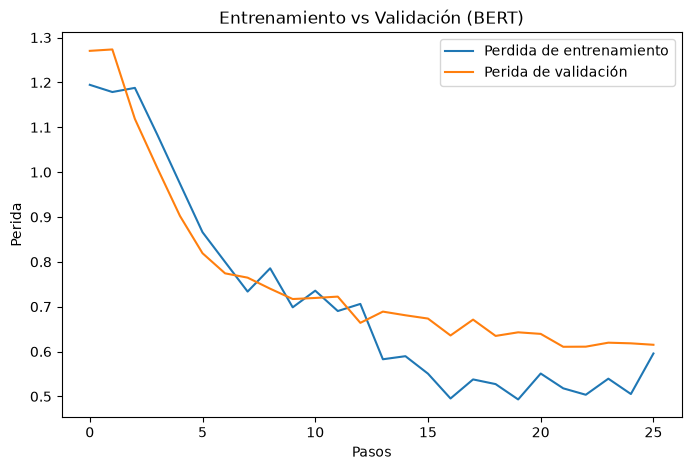

In [16]:
# Métricas
if not TRAIN:
    with open("bert_model/checkpoint-1300/trainer_state.json", "r") as f:
        data = json.load(f)

    log_history_ = data.get("log_history", [])
else:
    log_history_ = trainer.state.log_history

train_losses = [log["loss"] for log in log_history_ if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history_ if "eval_loss" in log]

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Perdida de entrenamiento")
plt.plot(eval_losses, label="Perida de validación")
plt.title("Entrenamiento vs Validación (BERT)")
plt.xlabel("Pasos")
plt.ylabel("Perida")
plt.legend()
plt.show()

## Justificación de hiperparametros

---
### Tratamiento del desbalance y de la decisión (Enfoques 0, 1 y 2)

Los tres enfoques reciben el mismo conjunto de datos, pero no necesariamente el mismo tratamiento

¿Por que se eligio un threshold calculado para cada clase en el enfoque 0 y 1?



1. **Ponderación de clases y experimentos de ablación.** En BERT, `pos_weight` en `BCEWithLogitsLoss`. En cada problema binario el positivo pesa $n_{neg}/n_{pos}$ veces más que el negativo, que es exactamente el cociente de pesos de BERT. Por otro lado, en las regresiones logísticas, realizando experimentos de hablación sobre varias configuraciones de los parametros `class_weight="balanced"` y `tune_thresholds` se obtuvo que la mejor configuración es con umbrales calculados sin balanceo de clases (Como se ve en la tabla de abajo). Las probabilidades de las clases raras casi nunca llegan a 0.5, así que el modelo no las predice, por lo que el umbral se tiene que ajustar a estos casos. Los umbrales por etiqueta capturan el beneficio y la ponderación no aporta. Además, si nuestra muestra es suficientemente representativa, no hay mejora en el desempeño de LR usando weight balancing: https://pastorjordi.github.io/blog/2022/balance_weights_logreg/

2. **Elección de umbral por etiqueta, ajustado en validación.** Para cada etiqueta se elige el umbral que maximiza su F1 en el conjunto de validación y luego se aplica fijo en prueba.  Pero, ¿por qué un umbral por etiqueta y no 0.5? El umbral es una regla de decisión posterior al modelo, no parte del entrenamiento. 0.5 solo es óptimo si las probabilidades están calibradas y los errores cuestan lo mismo. 

- Lipton, Z. C., Elkan, C., & Naryanaswamy, B. (2014). Optimal Thresholding of Classifiers to Maximize F1 Measure. *ECML PKDD*. https://arxiv.org/abs/1402.1892
- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On Calibration of Modern Neural Networks. *ICML*, PMLR 70:1321-1330. https://arxiv.org/abs/1706.04599

In [17]:
abl = pd.concat(
    [
        ablation_lr(
            "0. LaBSE + LR", e_train_bse, y_train, e_valid_bse, y_valid, C=best["C"]
        ),
        ablation_lr(
            "1. TF-IDF + LR",
            X_train_tfidf,
            y_train,
            X_valid_tfidf,
            y_valid,
            C=1.0,
            max_iter=500,
        ),
    ],
    ignore_index=True,
)

display(abl.round(4))

,enfoque,class_weight,umbrales,val_hamming,val_accuracy,val_macroF1,val_microF1
0,0. LaBSE + LR,none,0.5,0.0631,0.5062,0.4800,0.6720
1,0. LaBSE + LR,none,calculados,0.0652,0.5138,0.6727,0.7275
2,0. LaBSE + LR,balanced,0.5,0.1080,0.3231,0.5692,0.6411
3,0. LaBSE + LR,balanced,calculados,0.0686,0.5108,0.6528,0.7209
4,1. TF-IDF + LR,none,0.5,0.0665,0.4692,0.4428,0.6327
5,1. TF-IDF + LR,none,calculados,0.0660,0.5123,0.6116,0.6994
6,1. TF-IDF + LR,balanced,0.5,0.1231,0.3169,0.5110,0.5943
7,1. TF-IDF + LR,balanced,calculados,0.0723,0.4908,0.6027,0.6871


# 5. Evaluación
---

Vamos a comparar los tres enfoques con metricas adecuadas

### 5.1 Metricas generales por cada enfoque.

En clasificación **multilabel** cada muestra puede tener varias etiquetas a la vez. En este sentido  las métricas de clasificación tradicionales se adaptan de varias formas. Usamos seis métricas que miden aspectos distintos del desempeño.

**Notación:** $N$ = número de muestras, $L$ = número de etiquetas (10), $y_{ij}$ = valor real de la etiqueta $j$ en la muestra $i$, $\hat{y}_{ij}$ = valor predicho. Para cada etiqueta (o en total) se definen: **TP** (verdaderos positivos), **FP** (falsos positivos), **FN** (falsos negativos).

### 1. `hamming_loss`

$$\text{Hamming Loss} = \frac{1}{N \cdot L} \sum_{i=1}^{N} \sum_{j=1}^{L} \mathbb{1}\left[y_{ij} \neq \hat{y}_{ij}\right]$$

Es la fracción de pares (muestra, etiqueta) mal clasificados. Cada etiqueta de cada muestra cuenta como una decisión binaria independiente, y la métrica promedia los errores. Va de 0 a 1 y menor es mejor.

Es importante por ser la métrica base del baseline, así que es la que permite comparar directamente con el experimento original.
**Nota**: como las etiquetas son muy dispersas (1.15 positivas de 10 aprox), un modelo que no predice nada ya obtiene un Hamming Loss de aproximadamente $1.15/10 \approx 0.115$. No distingue entre un falso positivo y un falso negativo, y está dominada por los negativos, que son la gran mayoría.

### 2. `accuracy_score`

$$\text{Subset Accuracy} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\left[\mathbf{y}_i = \hat{\mathbf{y}}_i\right]$$

`accuracy_score`: cuenta una muestra como correcta solo si el conjunto completo de etiquetas coincide exactamente. Fallar una sola etiqueta de las 10 hace que toda la muestra cuente como error. Va de 0 a 1 y mayor es mejor.

Es la métrica más estricta y la más cercana a la pregunta práctica: *"¿el sistema entendió todo lo que el solicitante quiso decir?"*. Complementa a Hamming Loss: un modelo puede tener un Hamming Loss bajo (casi todas las decisiones individuales son correctas) y aun así una Subset Accuracy baja si se equivoca en una etiqueta de muchas muestras.


### 3. Micro Precision:  `precision_score(average='micro')`

$$\text{Precision}_{\text{micro}} = \frac{\sum_j TP_j}{\sum_j TP_j + \sum_j FP_j}$$

Devuelve de todas las etiquetas que el modelo predijo como positivas la proporción que era correcta. El promedio micro suma los TP y FP de todas las etiquetas antes de dividir, así que cada predicción individual pesa lo mismo.

Mide qué tan **confiable** es el modelo cuando afirma que una solicitud tiene cierto propósito. Una precisión baja significa muchas etiquetas "inventadas", lo que en un flujo de crédito puede traducirse en decisiones o clasificaciones erróneas que hay que corregir.


### 4. Micro Recall — `recall_score(average='micro')`

$$\text{Recall}_{\text{micro}} = \frac{\sum_j TP_j}{\sum_j TP_j + \sum_j FN_j}$$

Devuelve de todas las etiquetas que realmente existían la proporción que detectó el modelo.

Mmide cuántas intenciones reales se **pierden**. Un recall bajo significa que el modelo es conservador y deja muchas etiquetas sin asignar. 


### 5. Micro F1 — `f1_score(average='micro')`

$$F1_{\text{micro}} = \frac{2 \cdot \text{Precision}_{\text{micro}} \cdot \text{Recall}_{\text{micro}}}{\text{Precision}_{\text{micro}} + \text{Recall}_{\text{micro}}}$$

Es la media armónica de precisión y recall micro. La media armónica penaliza los desbalances: si una de las dos es muy baja, el F1 también lo es (no se puede "compensar" con la otra).Resume en un solo número el equilibrio entre precisión y recall. A diferencia de Hamming Loss, ignora los verdaderos negativos, que aquí son la gran mayoría, por lo que no se infla por predecir "nada".

### 6. Macro F1 — `f1_score(average='macro')`

$$F1_{\text{macro}} = \frac{1}{L} \sum_{j=1}^{L} F1_j$$

Calcula el F1 de cada etiqueta por separado y promedia los 10 valores con el mismo peso, sin importar cuántos ejemplos tenga cada una.

Como el dataset está desbalanceado- Con micro F1, un modelo puede verse bien ignorando por completo las clases pequeñas, pero Macro F1 expone ese fallo.

In [18]:
def evaluate_approach(
    y_true: Union[pd.DataFrame, np.ndarray],
    y_pred: np.ndarray,
    y_pred_prob: np.ndarray,
    approach_name: str,
) -> None:
    """Evalua un enfoque.

    Args:
        y_true (Union[pd.DataFrame, np.ndarray]): etiquetas de verdad.
        y_pred (np.ndarray): predicciones, despues de sigmoide
        y_pred_prob (np.ndarray): probabilidades, salidas de cada modelo
        approach_name (str): nombre.
    """
    h_loss = hamming_loss(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    micro_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
    micro_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "Enfoque": approach_name,
        "Hamming": h_loss,
        "Accuracy": accuracy,
        "Micro Precision": micro_precision,
        "Micro Recall": micro_recall,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }


print("---Evaluación---")

results_a0 = evaluate_approach(
    y_test, y_pred_a0, y_pred_prob_a0, "Enfoque 0: LaBSE + LR"
)
results_a1 = evaluate_approach(
    y_test, y_pred_a1, y_pred_prob_a1, "Enfoque 1: TF-IDF + LR"
)
results_a2 = evaluate_approach(y_test, y_pred_a2, y_pred_prob_a2, "Enfoque 2: BERT")

comparison_df = pd.DataFrame([results_a0, results_a1, results_a2])

print(comparison_df.to_string(index=False))

---Evaluación---
               Enfoque  Hamming  Accuracy  Micro Precision  Micro Recall  Micro F1  Macro F1
 Enfoque 0: LaBSE + LR 0.077538  0.463077         0.646192      0.708895  0.676093  0.597648
Enfoque 1: TF-IDF + LR 0.067846  0.526154         0.720999      0.661725  0.690091  0.609310
       Enfoque 2: BERT 0.071231  0.556923         0.669502      0.742588  0.704153  0.646293


### 5.2 Visualización

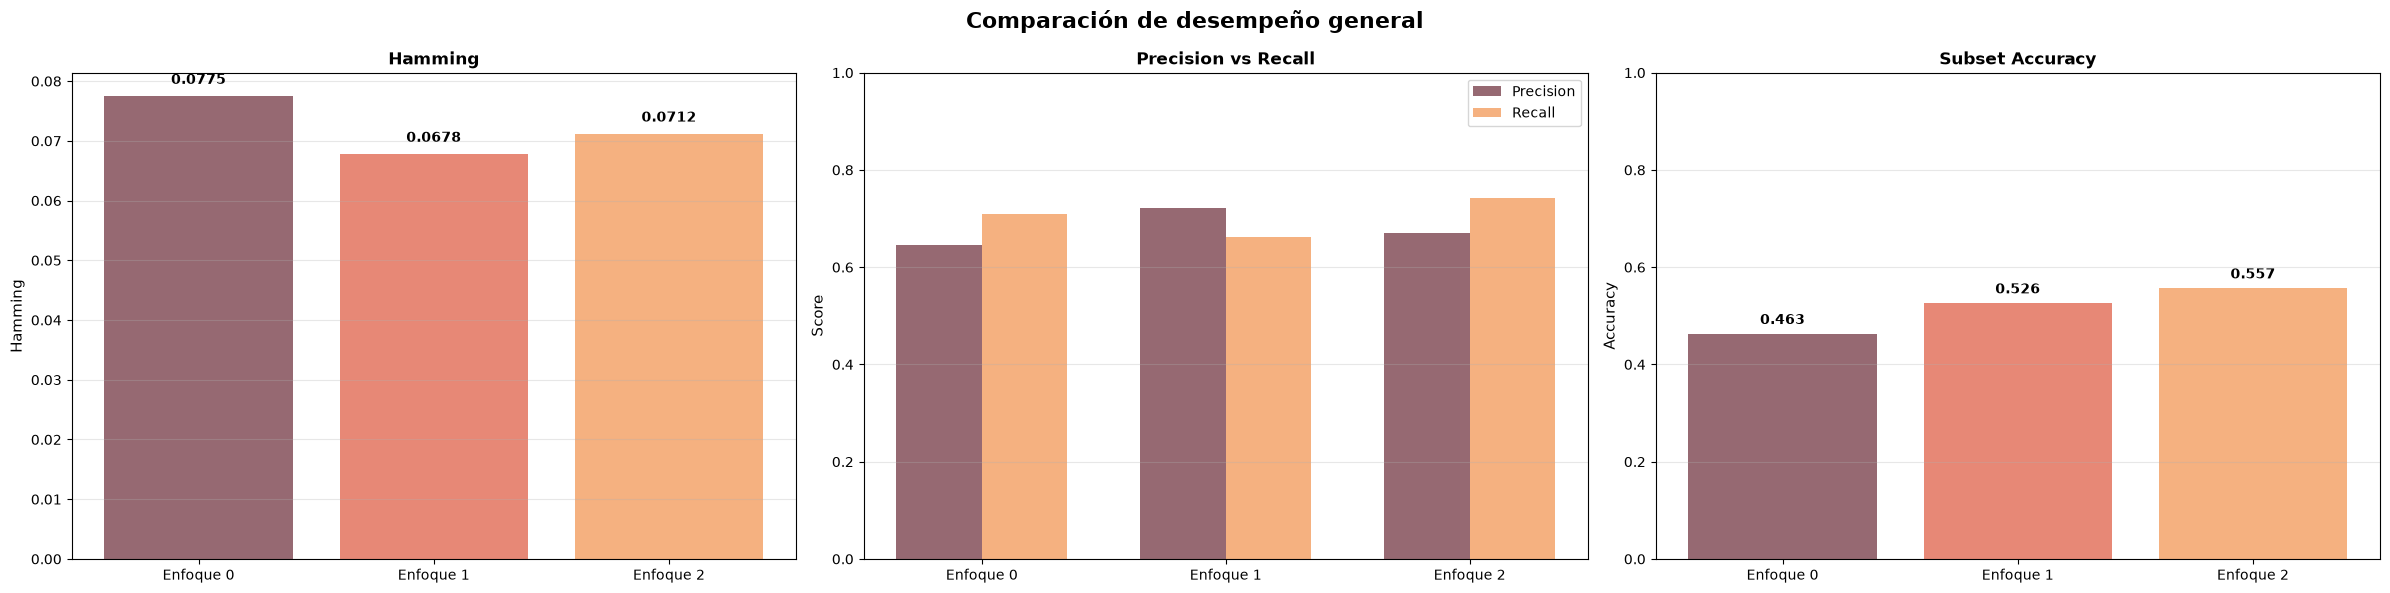

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle("Comparación de desempeño general", fontsize=16, fontweight="bold")

COLORS = ["#7C444F", "#E16A54", "#F39E60"]

# Hamming
approaches = comparison_df["Enfoque"].str.split(":").str[0]
axes[0].bar(approaches, comparison_df["Hamming"], color=COLORS, alpha=0.8)
axes[0].set_ylabel("Hamming", fontsize=11)
axes[0].set_title("Hamming", fontsize=12, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(comparison_df["Hamming"]):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")

# Precision vs Recall
x = np.arange(len(approaches))
width = 0.35
axes[1].bar(
    x - width / 2,
    comparison_df["Micro Precision"],
    width,
    label="Precision",
    color=COLORS[0],
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    comparison_df["Micro Recall"],
    width,
    label="Recall",
    color=COLORS[2],
    alpha=0.8,
)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_title("Precision vs Recall", fontsize=12, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(approaches)
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Accuracy
axes[2].bar(approaches, comparison_df["Accuracy"], color=COLORS, alpha=0.8)
axes[2].set_ylabel("Accuracy", fontsize=11)
axes[2].set_title("Subset Accuracy", fontsize=12, fontweight="bold")
axes[2].set_ylim([0, 1])
axes[2].grid(axis="y", alpha=0.3)
for i, v in enumerate(comparison_df["Accuracy"]):
    axes[2].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

Lo que podemos destacar de los graficos anteriores es lo siguiente:

1. **Hamming Loss.** El Enfoque 1 (TF-IDF + LR) es el que menos se equivoca por decisión, como proponía el documento, un enfoque sencillo enfocado a cada etiqueta tiende a ser mejor en este tipo de tareas. Pero como bien se mencionó arriba, esta métrica está dominada por los negativos (~1.15 etiquetas positivas de 10), así que las diferencias entre enfoques son pequeñas. Además, no es comparable directamente con el 0.0682 del documento (LASER, otra partición).

2. **Precision vs Recall** Ambos con promedio micro. En los graficos podemos ver que el enfoque 1 es mejor en precision pero peor en recall (hecho que veremos más adelante reflejado en el F1). Es decir, de los positivos que detectó el modelo, mucha de la proporción era verdadera, pero gran parte de los verdaderos positivos no los detecto: (no inventó mucho pero fué conservador y omitió varias etiquetas). BERT invierte la relación, efecto esperado de `pos_weight` y de los umbrales tuneados en validación.

3. **Accuracy** Aquí podemos ver que el mejor modelo en este sentido es BERT. Es un resultado de esperarse por la robustes del modelo.

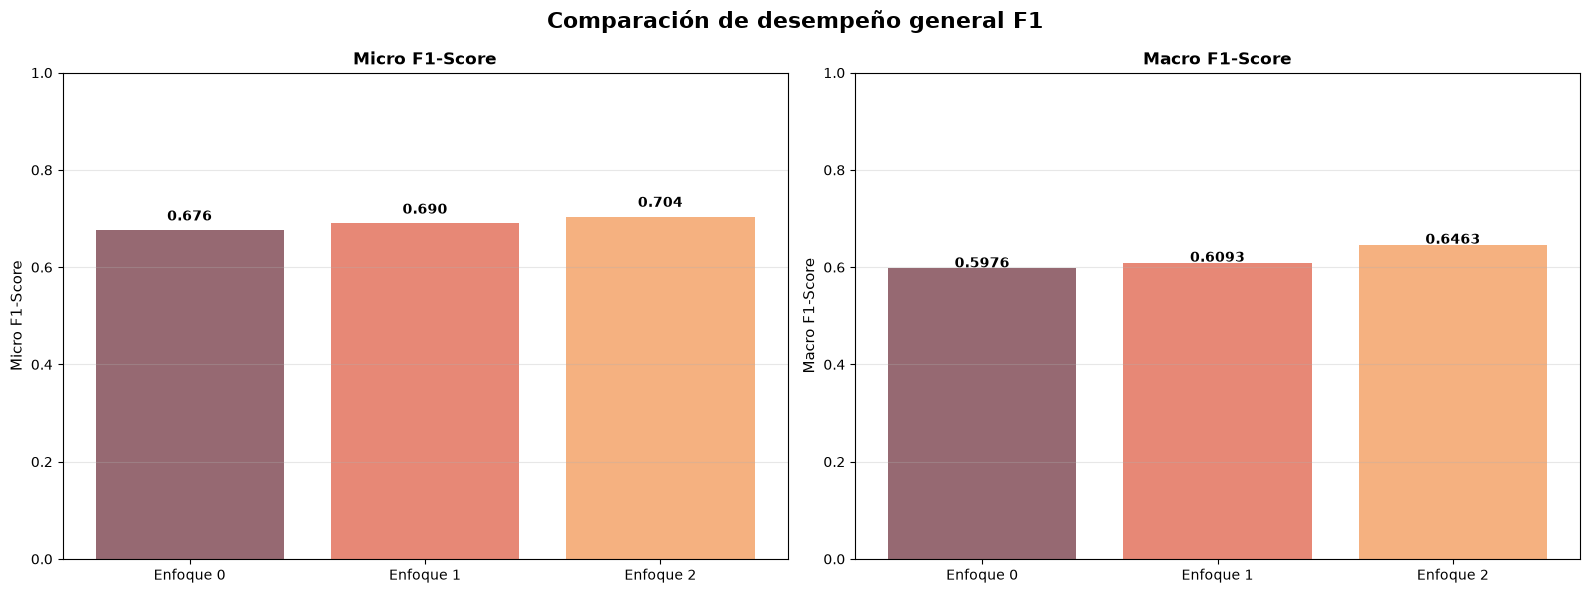

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Comparación de desempeño general F1", fontsize=16, fontweight="bold")

# Micro F1-Score
axes[0].bar(approaches, comparison_df["Micro F1"], color=COLORS, alpha=0.8)
axes[0].set_ylabel("Micro F1-Score", fontsize=11)
axes[0].set_title("Micro F1-Score", fontsize=12, fontweight="bold")
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)
for i, v in enumerate(comparison_df["Micro F1"]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

# Macro F1-Score
axes[1].bar(approaches, comparison_df["Macro F1"], color=COLORS, alpha=0.8)
axes[1].set_ylabel("Macro F1-Score", fontsize=11)
axes[1].set_title("Macro F1-Score", fontsize=12, fontweight="bold")
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)
for i, v in enumerate(comparison_df["Macro F1"]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

4. **Micro F1** Muy relacionado al grafico de precision vs recall. El que gana mejor balance es el enfoque 2, más complejo. 

5. **Macro F1** Finalmente, el Enfoque 2 gana en esta metrica. En otras palabras, en el dataset desbalanceado presenta un mejor desempeño al capturar la mejor proporción de positivos que es correcta y etiqueta como positivos la mayor cantidad correcta.

**Notas:**

- **Limitaciones.** Una sola partición y semilla: diferencias menores a ~0.02 no son concluyentes. Una alternativa para abordar el tema de las clases desbalanceadas, más alla de las configuraciones de hiperparametros es sin duda el data-augmentation o someter los modelos a cargas reales mediante un despliegue de shadow develoment.


En conclusión. Si el objetivo es cubrir las intenciones minoritarias (Macro F1), BERT es la mejor opción, con un costo mayor de cómputo. Si importan la simplicidad y la latencia, LaBSE + LR es competitivo y mejor que TF-IDF hablando en terminos de calidad (LaBSE o cualquier otro embedding tiene la capacidad de reconocer relaciones semánticas complejas). Una opción práctica es un esquema híbrido: LaBSE + LR como ruta rápida y BERT para casos de baja confianza. Próximos pasos: intervalos de confianza por bootstrap, mismo tratamiento de umbrales en los tres enfoques y análisis de errores en `temp` y `sueldo`.

### Un paso más: Metricas por clase y Average Presicion

Para evaluar el desempeño de cada modelo en cada clase podemos hacer una visualización sobre las metricas en cada una. Por otro lado en el documento se menciona que una metrica tomada en cuenta es Average Presicion. También podemos ver su desempeño.

In [21]:
from sklearn.metrics import classification_report

y_true = y_test.to_numpy()

MODELS = {
    "LaBSE + LR": (y_pred_a0, y_pred_prob_a0),
    "TF-IDF + LR": (y_pred_a1, y_pred_prob_a1),
    "BERT": (y_pred_a2, y_pred_prob_a2),
}

rows = []
for name, (y_pred, _) in MODELS.items():
    rep = classification_report(
        y_true, y_pred, target_names=LABELS, output_dict=True, zero_division=0
    )
    for lab in LABELS + ["micro avg", "macro avg"]:
        rows.append(
            {
                "Clase": lab,
                "Enfoque": name,
                "Precision": rep[lab]["precision"],
                "Recall": rep[lab]["recall"],
                "F1": rep[lab]["f1-score"],
            }
        )

# Tabla comparativa: Precision / Recall / F1 de cada enfoque, lado a lado
report_df = pd.DataFrame(rows)
order = LABELS + ["micro avg", "macro avg"]
report_table = (
    report_df.pivot(
        index="Clase", columns="Enfoque", values=["Precision", "Recall", "F1"]
    )
    .swaplevel(axis=1)
    .reindex(columns=list(MODELS), level=0)
    .reindex(order)
)
report_table.insert(
    0, ("", "Soporte (test)"), list(y_true.sum(axis=0)) + [int(y_true.sum())] * 2
)

display(report_table.round(3))

Enfoque                  LaBSE + LR               TF-IDF + LR                \
          Soporte (test)  Precision Recall     F1   Precision Recall     F1   
Clase                                                                         
crec                  70      0.453  0.557  0.500       0.569  0.414  0.479   
cred                  29      0.696  0.552  0.615       0.731  0.655  0.691   
equ                  171      0.831  0.719  0.771       0.837  0.661  0.739   
inic                  49      0.652  0.612  0.632       0.714  0.612  0.659   
inv                  230      0.709  0.826  0.763       0.743  0.878  0.805   
mkt                   33      0.659  0.879  0.753       0.862  0.758  0.806   
no                    50      0.780  0.780  0.780       0.735  0.500  0.595   
renta                 71      0.484  0.648  0.554       0.611  0.465  0.528   
sueldo                24      0.389  0.292  0.333       0.727  0.333  0.457   
temp                  15      0.194  0.467  0.275       0.259  0.467  0.333   
micro avg            742      0.646  0.709  0.676       0.721  0.662  0.690   
macro avg            742      0.585  0.633  0.598       0.679  0.574  0.609   

Enfoque        BERT                
          Precision Recall     F1  
Clase                              
crec          0.402  0.471  0.434  
cred          0.647  0.759  0.698  
equ           0.759  0.830  0.793  
inic          0.519  0.571  0.544  
inv           0.777  0.817  0.797  
mkt           0.763  0.879  0.817  
no            0.818  0.720  0.766  
renta         0.505  0.718  0.593  
sueldo        0.708  0.708  0.708  
temp          0.294  0.333  0.312  
micro avg     0.670  0.743  0.704  
macro avg     0.619  0.681  0.646

AP por clase (test):


,Prevalencia (AP de un clasificador al azar),LaBSE + LR,TF-IDF + LR,BERT,Soporte (test)
crec,0.108,0.543,0.518,0.415,70
cred,0.045,0.785,0.725,0.728,29
equ,0.263,0.850,0.795,0.849,171
inic,0.075,0.686,0.673,0.624,49
inv,0.354,0.840,0.862,0.851,230
mkt,0.051,0.883,0.827,0.892,33
no,0.077,0.849,0.668,0.821,50
renta,0.109,0.562,0.524,0.643,71
sueldo,0.037,0.422,0.431,0.753,24
temp,0.023,0.329,0.279,0.207,15



AP global (test):


,Macro AP,Micro AP
Enfoque,,
LaBSE + LR,0.675,0.761
TF-IDF + LR,0.630,0.730
BERT,0.678,0.696


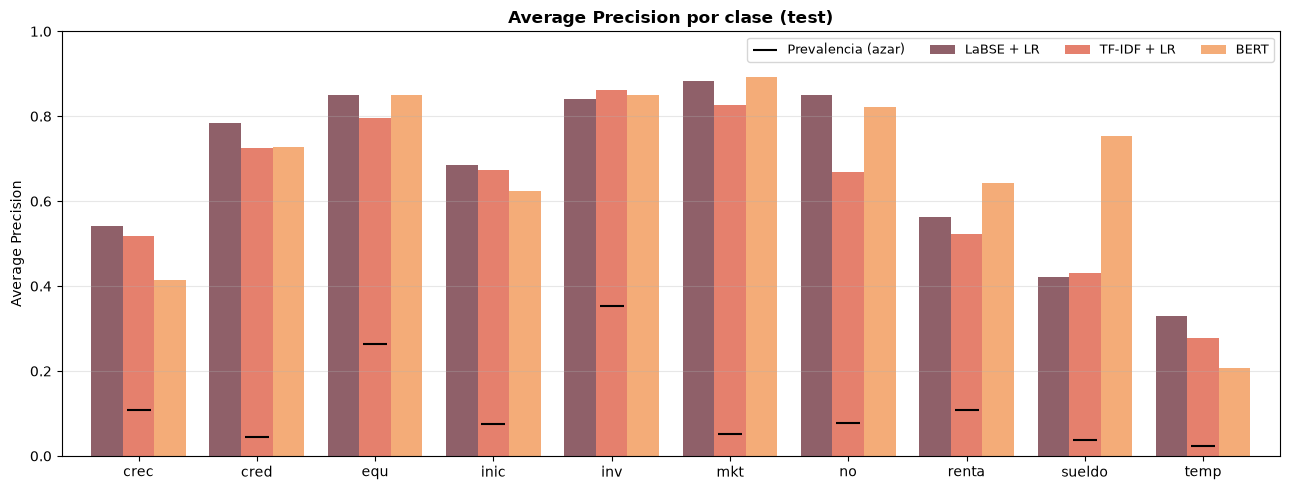

In [22]:
from sklearn.metrics import average_precision_score

# AP se calcula con PROBABILIDADES (no con las predicciones binarias): no depende del umbral.
ap_per_class, ap_global = {}, []
for name, (_, y_prob) in MODELS.items():
    ap_per_class[name] = average_precision_score(y_true, y_prob, average=None)
    ap_global.append(
        {
            "Enfoque": name,
            "Macro AP": average_precision_score(y_true, y_prob, average="macro"),
            "Micro AP": average_precision_score(y_true, y_prob, average="micro"),
        }
    )

ap_df = pd.DataFrame(ap_per_class, index=LABELS)
ap_df.insert(0, "Prevalencia (AP de un clasificador al azar)", y_true.mean(axis=0))
ap_df["Soporte (test)"] = y_true.sum(axis=0)

print("AP por clase (test):")
display(ap_df.round(3))
print("\nAP global (test):")
display(pd.DataFrame(ap_global).set_index("Enfoque").round(3))

# Gráfica: AP por clase y enfoque; la línea negra es la prevalencia (referencia al azar)
ax = ap_df[list(MODELS)].plot.bar(figsize=(13, 5), color=COLORS, alpha=0.85, width=0.8)
ax.scatter(
    range(len(LABELS)),
    ap_df["Prevalencia (AP de un clasificador al azar)"],
    color="black",
    marker="_",
    s=300,
    label="Prevalencia (azar)",
    zorder=3,
)
ax.set_ylim(0, 1)
ax.set_ylabel("Average Precision")
ax.set_xlabel("")
ax.set_title("Average Precision por clase (test)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(ncol=4, fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Otro punto a favor de escoger el enfoque hibrido es lo que se muestra en la grafica de arriba. LaBSE y BERT presentan mejor Average presicion en cada clase.


# 6. Notas para deployment
---

### 6.1 Resumen de la decisión

| Enfoque | Hamming ↓ | Micro F1 | Macro F1 | Costo de entrenamiento | Requisito de inferencia |
|---|---|---|---|---|---|
| 0. LaBSE + LR | 0.0775 | 0.676 | 0.5976 | Bajo (minutos, CPU) | Forward de LaBSE + LR |
| 1. TF-IDF + LR | 0.0678 | 0.690 | 0.6093 | Mínimo | Solo CPU, sub-ms |
| 2. BERT fine-tune | 0.0712 | 0.704 | 0.6463 | Alto (GPU) | Forward de BERT |

**Recomendaciones:** 

- Desplegar primero el **Enfoque 0 (LaBSE + LR)** como modelo de producción, ponerlo a prueba en producción en shadow development junto con BERT, y decidir entre un modelo único o un esquema híbrido con datos reales y no con supuestos.

- **Por qué no solo BERT desde el día uno:** su ventaja sobre LaBSE + LR es pequeña en Micro F1 y su mayor aporte es en Macro F1 y recall. Eso justifica evaluarlo en producción.

---

### 6.2 Antes de diseñar

El diseño depende de metricas que aun no se pueden medir, en este sentido:

1. **Latencia por modelo** en el hardware objetivo, con textos de ~20 tokens. LaBSE y BERT-base tienen un costo de cómputo similar por forward (la diferencia está sobre todo en el tamaño de la tabla de embeddings), entonces la ventaja de LaBSE + LR frente a BERT está en el **entrenamiento y la GPU**, no necesariamente en la latencia. 
2. **Tamaño en disco y memoria** LaBSE ocupa del orden de GB, no "<500MB".
3. **Calibración de probabilidades.**

---

### 6.3 Arquitectura preliminar

```
[Texto de la solicitud]
        │
        ▼
[Preprocesamiento + validación de entrada]
        │
        ▼
[Modelo principal: LaBSE + LR  → probabilidades calibradas por etiqueta]
        │
        ▼
 ¿Alguna etiqueta cerca de su umbral (|p − umbral| < margen)
  o ninguna etiqueta sobre su umbral?
   │                         │
  NO                        SÍ
   │                         ▼
   │          [Modelo profundo: BERT  → probabilidades calibradas]
   │                         │
   │                         ▼
   │          ¿Sigue ambiguo?  ──SÍ──▶ [Cola de revisión humana]
   │                         │
   ▼                         ▼
[Etiquetas finales + probabilidades + versión del modelo → log]
```

Decisiones de diseño:

- **Definición de "incertidumbre" en multilabel.** Con 10 salidas independientes no existe una única confianza. Se propone el margen respecto al umbral por etiqueta (el mismo que se ajustó en validación) y el caso "ninguna etiqueta activa", que en este dataset casi siempre es un error, porque todas las muestras tienen al menos una.
- **Umbrales por etiqueta**, no 0.5 fijo, ajustados en validación y versionados junto al modelo. Un cambio de umbral es un cambio de modelo.
- **Humano en el ciclo** para los casos que siguen ambiguos. Sus correcciones se convierten en datos de reentrenamiento, y son la mejor fuente de ejemplos para `temp` y `sueldo`.
- **Si la medición del punto 6.2 muestra que BERT cuantizado cumple la latencia en CPU**, el enrutador no se justifica y se despliega un solo modelo. Menos piezas significan menos fallos y menos mantenimiento.


Es decir, cuando una predicción es dudosa, pasa por el modelo BERT. En este sentido, estaríamos corriendo dos modelos secuencialmente cuando nos encontremos con casos dudosos. En costos, como la latencia que estaríamos duplicando en algunas ocasiones, tendriamos algo como costo_promedio = $costo_rapido + f × costo_profundo$, donde f es la proporción de casos dudosos que se tienen. Un modelo único (BERT optimizado o LaBSE + LR según el costo medido); es importante destacar que este enfoque híbrido solo podría generealizarse si la curva de validación demuestra beneficio. En otro caso sería conveniento usar un solo modelo.


---

### 6.4 Plan por fases con criterios de salida

| Fase | Duración estimada | Actividad | Criterio para avanzar |
|---|---|---|---|
| 0. Preparación | 1–2 semanas | Medir latencia, memoria y calibración. Definir API y esquema de logs | Latencia y costo medidos. Calibración aceptable |
| 1. Modo sombra | 2–4 semanas | LaBSE + LR en producción. BERT y TF-IDF corren en paralelo sin afectar decisiones. Se comparan predicciones | Sin degradación frente al offline. datos suficientes para evaluar |
| 2. Evaluación con etiquetas reales | 2–4 semanas | Muestra revisada manualmente. Bootstrap para intervalos de confianza | Decisión estadísticamente fundada: modelo único vs. híbrido |
| 3. Despliegue gradual | 2–4 semanas | Canary (5% → 25% → 100%) con *rollback* automático | Métricas dentro de los umbrales de alerta |
| 4. Operación | Continuo | Monitoreo, reentrenamiento, revisión de errores | Revisión trimestral de la arquitectura |

Los plazos son estimaciones y dependen del volumen de solicitudes y de la capacidad de etiquetado.

---

### 6.5 Monitoreo y reentrenamiento

**Para tener encuenta**

- **Calidad (con retraso):** F1 y Hamming Loss sobre una muestra etiquetada semanalmente, y por etiqueta, con especial atención a `temp` y `sueldo`.
- **Drift de entrada:** longitud del texto, vocabulario nuevo (tasa de tokens desconocidos), distancia de los embeddings respecto al conjunto de entrenamiento (PSI o similar).
- **Drift de salida:** distribución de etiquetas predichas, proporción de "ninguna etiqueta", número promedio de etiquetas por solicitud (hoy ≈ 1.15).
- **Operación:** latencia, errores, tasa de envío a BERT y a revisión humana.
- **Estacionalidad:** la categoría `temp` (temporada) probablemente cambia con el calendario, así que conviene evaluar el rendimiento por mes.

**Reentrenamiento:** disparado por drift o por caída de métricas, no solo por calendario. Cada versión pasa por una *puerta de calidad* (no empeorar Macro F1 ni ninguna etiqueta crítica), se registra con sus datos, umbrales y semilla, y se despliega con *canary*. Se conserva siempre la versión anterior para *rollback*.

---

### 6.6 Riesgos y mitigaciones

| Riesgo | Impacto | Mitigación |
|---|---|---|
| Etiquetas ruidosas (textos cortos y ambiguos) | Techo de rendimiento bajo; métricas inestables | Auditoría de etiquetas, guía de anotación, medir acuerdo entre anotadores |
| Pocos ejemplos de `temp` y `sueldo` | Métricas ruidosas, recall bajo | Priorizarlos en la cola de revisión humana; aumentación de datos; *focal loss* |
| Probabilidades mal calibradas | El enrutador envía casos equivocados | Calibración por etiqueta; monitorear ECE |
| Drift de lenguaje (jerga regional, nuevos giros de negocio) | Degradación silenciosa | Monitoreo de entrada y salida; reentrenamiento disparado por drift |
| Dependencia de un servicio de descarga de modelos | Fallo en el arranque | Artefactos empaquetados y versionados internamente; sin descargas en tiempo de ejecución |
| Datos personales o sensibles en el texto libre | Riesgo de privacidad | Minimización, enmascarado de PII en los logs y política de retención |

---

### 6.7 Consideraciones de negocio y cumplimiento

- **Rol de la predicción.** Este modelo **clasifica el destino declarado del crédito**. No debe usarse, sin una validación adicional, como insumo directo de una decisión de otorgamiento. Si en el futuro participa en decisiones de crédito, hay que revisar requisitos de explicabilidad, trazabilidad y no discriminación aplicables.
- **Trazabilidad.** Cada predicción se registra con versión del modelo, umbrales, probabilidades y ruta seguida (rápida, profunda o humana), para poder auditar cualquier resultado.
- **Costo.** El análisis debe comparar el costo mensual total (cómputo de inferencia, GPU de entrenamiento, revisión humana, mantenimiento) frente a la ganancia de Macro F1. Una mejora de unos puntos puede no justificar una infraestructura de GPU permanente.

---

**Miguel Angel Liera Montaño**  
AI Engineer | Ejercicio de aplicación
*30 de Septiembre, 2026*